In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

Matplotlib is building the font cache; this may take a moment.


In [2]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [3]:
train_dir = r"C:\Users\NITESH\Downloads\Medical Dataset\chest_xray"
val_dir   = r"C:\Users\NITESH\Downloads\Medical Dataset\chest_xray"
test_dir  = r"C:\Users\NITESH\Downloads\Medical Dataset\chest_xray"

In [4]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [6]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 5840 files belonging to 2 classes.
Found 5840 files belonging to 2 classes.
Found 5840 files belonging to 2 classes.


In [7]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

In [8]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

c:\Users\NITESH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.8889 - loss: 0.3629 - val_accuracy: 0.8932 - val_loss: 0.3407
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.8932 - loss: 0.3501 - val_accuracy: 0.8932 - val_loss: 0.3369
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8932 - loss: 0.3384 - val_accuracy: 0.8932 - val_loss: 0.3093
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - accuracy: 0.8932 - loss: 0.3192 - val_accuracy: 0.8932 - val_loss: 0.3115
Epoch 5/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.8932 - loss: 0.3090 - val_accuracy: 0.8932 - val_loss: 0.2915
Epoch 6/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8932 - loss: 0.2939 - val_accuracy: 0.8932 - val_loss: 0.2685
Epoch 7/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8938 - loss: 0.2867 - val_accuracy: 0.8932 - val_loss: 0.2673
Epoch 8/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.8955 - loss: 0.2707 - val_accu

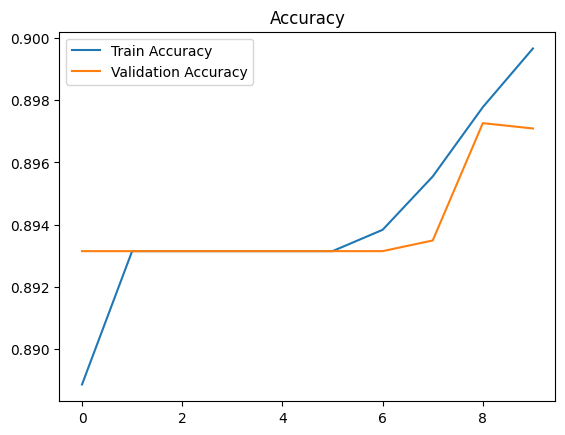

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

In [12]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

183/183 ━━━━━━━━━━━━━━━━━━━━ 64s 350ms/step - accuracy: 0.8971 - loss: 0.2365
Test Accuracy: 0.8970890641212463


In [13]:
model.save("medical_cnn_model.h5")

In [25]:
import os
print(os.path.exists("C:/Users/NITESH/Downloads/Medical Dataset/chest_xray/train"))

True


In [27]:
import numpy as np
import cv2
import os

# Use correct path (VERY IMPORTANT)
img_path = "C:/Users/NITESH/Downloads/Medical Dataset/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

# Check if file exists
if not os.path.exists(img_path):
    print("❌ Image path is wrong!")
    print("Check this folder manually:")
    print("C:/Users/NITESH/Downloads/Medical Dataset/chest_xray/test/NORMAL")
else:
    # Load image
    img = cv2.imread(img_path)

    if img is None:
        print("❌ Image not loaded (maybe wrong extension like .jpg/.jpeg)")
    else:
        # Resize
        img = cv2.resize(img, (128,128))

        # Normalize
        img = img / 255.0

        # Reshape
        img = np.reshape(img, (1,128,128,3))

        # Predict
        prediction = model.predict(img)

        print("Raw Prediction:", prediction)

        if prediction > 0.5:
            print("🦠 PNEUMONIA DETECTED")
        else:
            print("✅ NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Raw Prediction: [[0.41936874]]
✅ NORMAL


In [31]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 966.6 kB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.0 MB 777.5 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.0 MB 777.5 kB/s eta 0:00:10
   ----- ---------------------------------- 1.0/8.0 MB 860.9 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.0 MB 915.1 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.0 MB 954.6 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.0 MB 883.9 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.0 MB 883.9 kB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.0 MB 875.1 kB/s eta 0:00:07
   ----------- -------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 966ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [29]:
y_pred = np.array(y_pred)
y_pred = (y_pred > 0.5).astype(int)

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  24  600]
 [   1 5215]]


In [33]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.04      0.07       624
   PNEUMONIA       0.90      1.00      0.95      5216

    accuracy                           0.90      5840
   macro avg       0.93      0.52      0.51      5840
weighted avg       0.90      0.90      0.85      5840

